In [19]:
source("./src/slingshot_functions.r")
library(qs)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


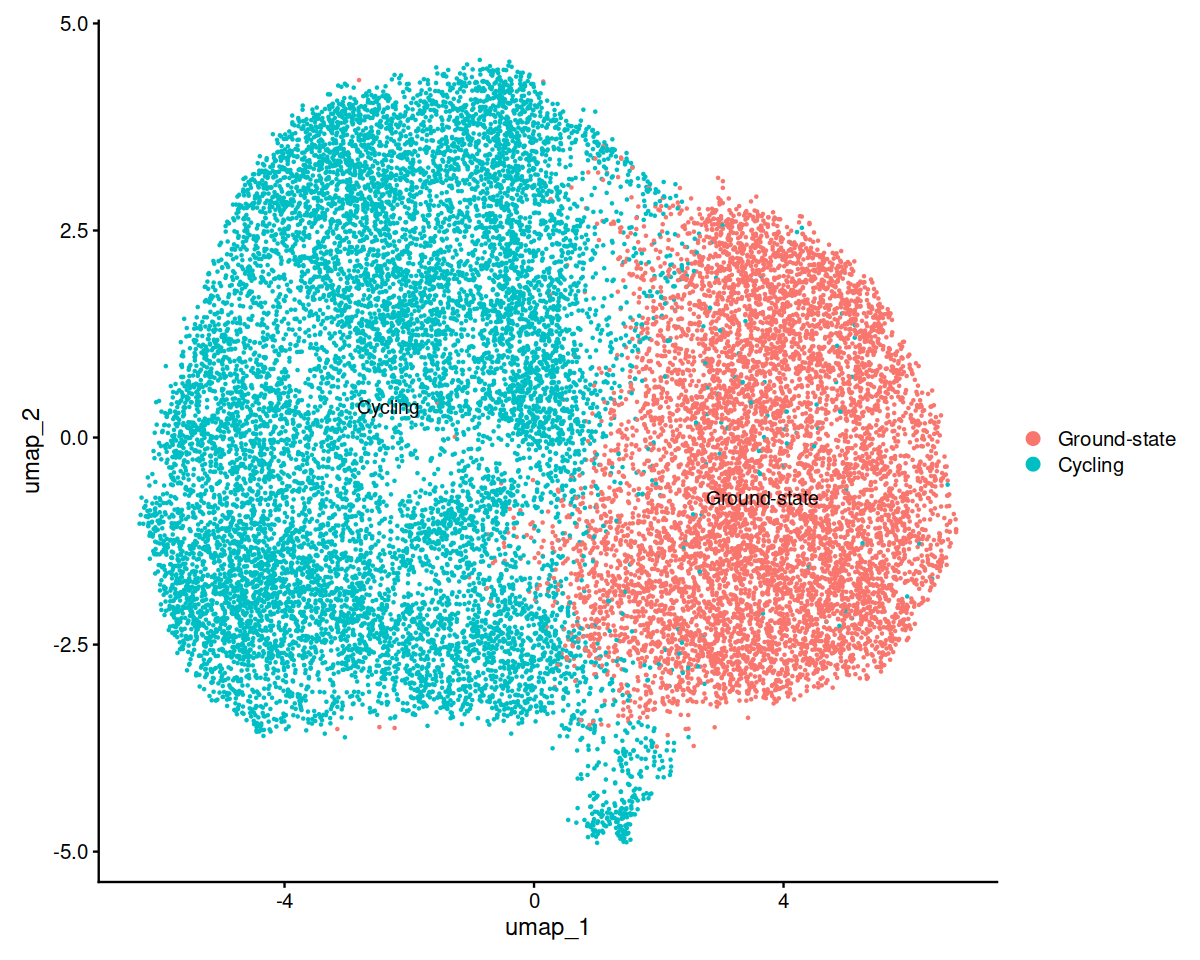

In [2]:
options(repr.plot.width=10, repr.plot.height=8)
seurat_obj <- qread("../Data/out/seurat_induction_8_24_hrs_annotated.qs")
seurat_obj <- SetIdent(seurat_obj, value="cell_label")
DimPlot(seurat_obj, label=TRUE)

In [3]:
unique(seurat_obj@meta.data$sample_names)

[1] "0 ng/mL, 0 hrs"    "500 ng/mL, 24 hrs" "500 ng/mL, 8 hrs"

In [4]:
table(seurat_obj@meta.data$cell_label, seurat_obj@meta.data$orig.ident)

              
               SeuratProject
  Ground-state          7856
  Cycling              12712

In [5]:
singlecell_obj <- as.SingleCellExperiment(seurat_obj, assay='RNA')
singlecell_obj

class: SingleCellExperiment 
dim: 20080 20568 
metadata(0):
assays(2): counts logcounts
rownames(20080): AL627309.5 LINC01409 ... AC245140.1 LINC00266-4P
rowData names(0):
colnames(20568): Dbt-0-0hr_AAACCCAAGAGAGGGC-1_1_1_1
  Dbt-0-0hr_AAACCCACAATGCAGG-1_1_1_1 ...
  Dbt-500-8hr_TTTGTTGGTTGTGTTG-1_1 Dbt-500-8hr_TTTGTTGTCATAGAGA-1_1
colData names(46): orig.ident nCount_RNA ... cell_label ident
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(0):

In [11]:
options(repr.plot.width = 12, repr.plot.height = 10)
slingshot_obj <- slingshot(singlecell_obj, 
                           clusterLabels    = "cell_label", 
                           reducedDim       = "UMAP", 
                           shrink        = 0.99,
                           extend        = "n",
                           allow.breaks  = TRUE,
                           stretch       = 0.0,
                           thresh        = 0.001
                          )

slingLineages(slingshot_obj)

$Lineage1
[1] "Cycling"      "Ground-state"

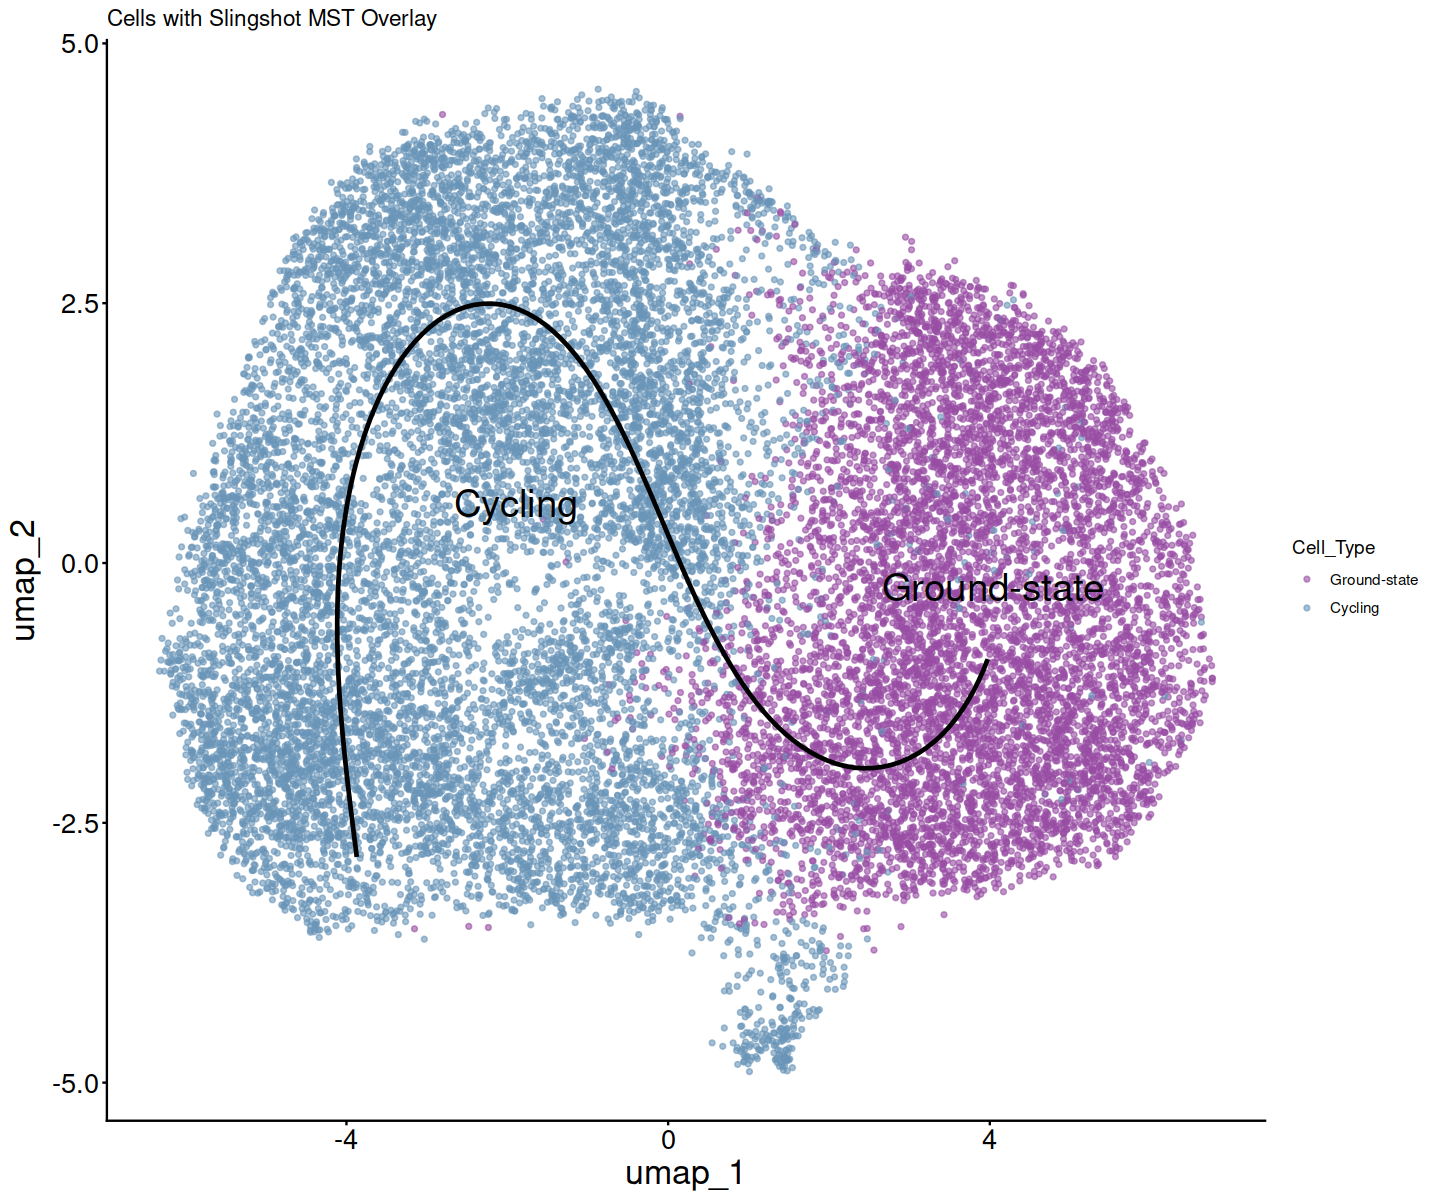

In [20]:
cluster_colors <- c(
  "Cycling" = "#6A95B8",
  "Ground-state" = "#984EA3"
)

cell_plot <- plot_slingshot_trajectory_trimmed(
  seurat_obj,
  slingshot_obj,
  annot_column = "cell_label",
  cluster_colors = cluster_colors,
  point_size = 1.0,
  point_alpha = 0.6
)

ggsave(
  "./out/slingshot_trajectory_8_24_hrs_annotated.png",
  plot = cell_plot,
  width = 8,
  height = 6,
  dpi = 300
)

cell_plot

In [15]:
qsave(slingshot_obj, "./out/slingshot_obj_8_24_hrs_annotated.qs")

In [16]:
slingshot_obj

class: SingleCellExperiment 
dim: 20080 20568 
metadata(0):
assays(2): counts logcounts
rownames(20080): AL627309.5 LINC01409 ... AC245140.1 LINC00266-4P
rowData names(0):
colnames(20568): Dbt-0-0hr_AAACCCAAGAGAGGGC-1_1_1_1
  Dbt-0-0hr_AAACCCACAATGCAGG-1_1_1_1 ...
  Dbt-500-8hr_TTTGTTGGTTGTGTTG-1_1 Dbt-500-8hr_TTTGTTGTCATAGAGA-1_1
colData names(48): orig.ident nCount_RNA ... slingshot
  slingPseudotime_1
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(0):